<a href="https://colab.research.google.com/github/Lawson-Dong/SINDy_code_reproduction/blob/main/Bagging_vs_Boosting_vs_Stacking(ESINDy%EF%BC%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ENSEMBLE SINDY INTEGRATION STRATEGY COMPARISON
Comparing Bagging vs Boosting vs Stacking

Experiment Configuration:
  Noise levels: [0.0, 0.1, 0.3, 0.5]
  Ensemble size: 50 models
  Independent runs: 3

Testing Noise Level: sigma = 0.0

  Run 1/3:
    Training Bagging Ensemble...
  Computing derivatives...
    Trained 50/50 models
    Training Boosting Ensemble...
  Computing derivatives...
    Trained 50/50 models
    Training Stacking Ensemble...
  Computing derivatives...
    Trained 50 base models

  Run 2/3:
    Training Bagging Ensemble...
  Computing derivatives...
    Trained 50/50 models
    Training Boosting Ensemble...
  Computing derivatives...
    Trained 50/50 models
    Training Stacking Ensemble...
  Computing derivatives...
    Trained 50 base models

  Run 3/3:
    Training Bagging Ensemble...
  Computing derivatives...
    Trained 50/50 models
    Training Boosting Ensemble...
  Computing derivatives...
    Trained 50/50 models
    Training Stacking Ensemble...
  Com

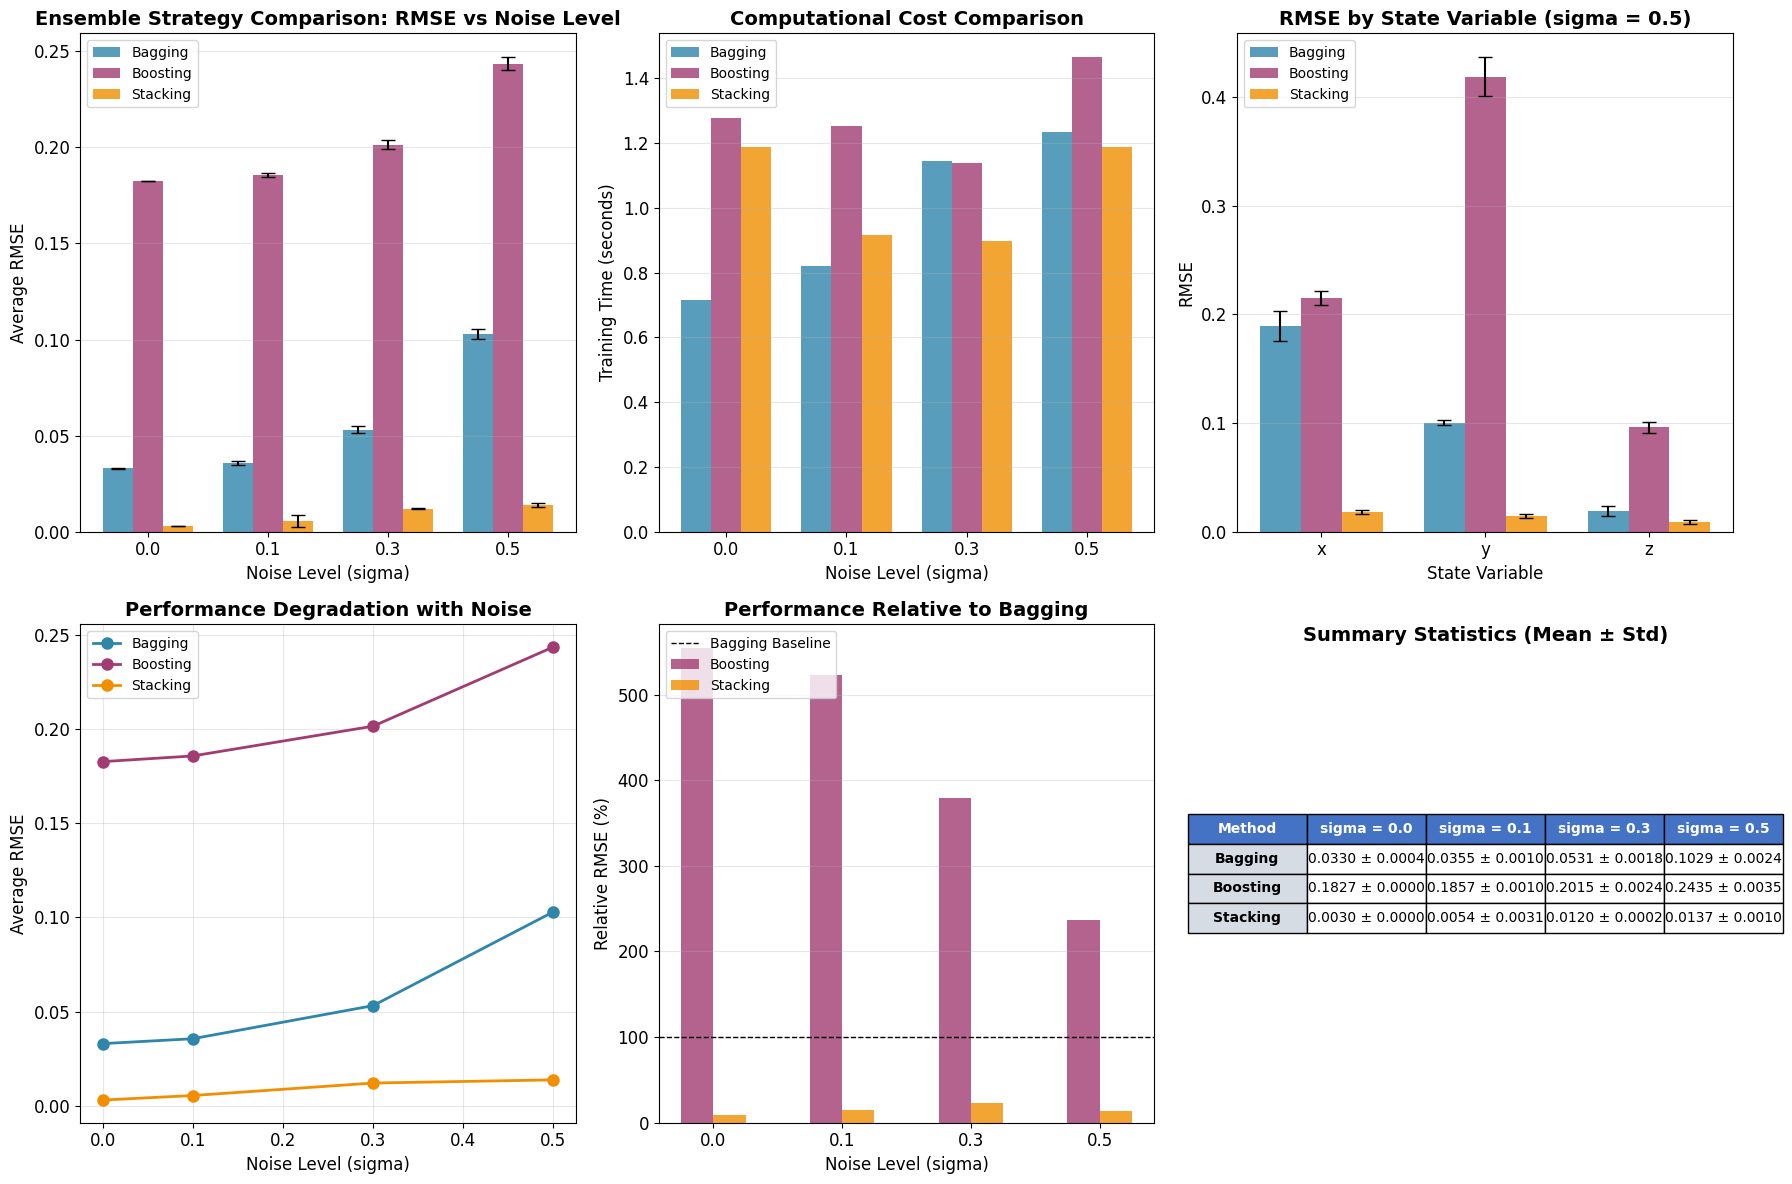


EXPERIMENT COMPLETE


In [11]:
"""
Ensemble SINDy Integration Strategy Comparison Experiment
Comparing Bagging vs Boosting vs Stacking under different noise scenarios

Based on ESINDy architecture
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.signal import savgol_filter
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from itertools import combinations_with_replacement
import warnings
import random
import os
import time
from abc import ABC, abstractmethod

warnings.filterwarnings('ignore')

# Plotting configuration
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed=42):
    """Fix random seeds for reproducibility"""
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


# ============================================================================
# Part 1: Base SINDy Model
# ============================================================================

class BaseSINDy:
    """Base SINDy model providing shared derivative computation and feature library construction"""

    def __init__(self, poly_degree=2, threshold=0.15, sg_window=11, sg_order=3,
                 use_reduced_features=True):
        self.poly_degree = poly_degree
        self.threshold = threshold
        self.sg_window = sg_window
        self.sg_order = sg_order
        self.use_reduced_features = use_reduced_features
        self.feature_names = None

    def _compute_derivative_sg(self, X, dt):
        """Compute derivatives using Savitzky-Golay filtering for noise robustness"""
        n_samples, n_states = X.shape
        dX = np.zeros_like(X)
        for i in range(n_states):
            X_smoothed = savgol_filter(X[:, i], self.sg_window, self.sg_order)
            dX[:, i] = np.gradient(X_smoothed, dt)
        return dX

    def _create_reduced_features(self, X):
        """Create reduced feature library with physically relevant terms only"""
        x = X[:, 0:1]
        y = X[:, 1:2]
        z = X[:, 2:3]
        features = [x, y, z, x*y, x*z, y*z]
        Theta = np.hstack(features)
        self.feature_names = ['x', 'y', 'z', 'x*y', 'x*z', 'y*z']
        return Theta

    def _create_polynomial_features(self, X, fit=False):
        """Create polynomial feature library with NaN checking"""
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            raise ValueError("Input data contains NaN or Inf")
        if self.use_reduced_features:
            return self._create_reduced_features(X)
        else:
            if fit or not hasattr(self, 'poly'):
                self.poly = PolynomialFeatures(degree=self.poly_degree, include_bias=False)
                Theta = self.poly.fit_transform(X)
                n_features = X.shape[1]
                feature_names = []
                for d in range(1, self.poly_degree + 1):
                    for combo in combinations_with_replacement(range(n_features), d):
                        feature_name = ' * '.join([f'x{i+1}' for i in combo])
                        feature_names.append(feature_name)
                self.feature_names = feature_names
            else:
                Theta = self.poly.transform(X)
            return Theta


# ============================================================================
# Part 2: Bagging Ensemble SINDy
# ============================================================================

class BaggingSINDy(BaseSINDy):
    """Bagging Ensemble SINDy - Bootstrap Aggregating"""

    def __init__(self, poly_degree=2, threshold=0.15, n_estimators=80,
                 subsample_ratio=0.8, noise_std=0.05, sg_window=11, sg_order=3,
                 use_reduced_features=True):
        super().__init__(poly_degree, threshold, sg_window, sg_order, use_reduced_features)
        self.n_estimators = n_estimators
        self.subsample_ratio = subsample_ratio
        self.noise_std = noise_std
        self.models = []
        self.coefficients = []
        self.inclusion_probabilities = None
        self.final_coefficients = None

    def _bootstrap_sample(self, X, y):
        """Create bootstrap sample with optional noise augmentation"""
        n_samples = X.shape[0]
        sample_size = max(1, int(n_samples * self.subsample_ratio))
        sample_size = min(sample_size, n_samples)
        indices = np.random.choice(n_samples, size=sample_size, replace=True)
        X_sample = X[indices].copy()
        y_sample = y[indices].copy()
        if self.noise_std > 0:
            X_sample += np.random.normal(0, self.noise_std, X_sample.shape)
            y_sample += np.random.normal(0, self.noise_std, y_sample.shape)
        return X_sample, y_sample

    def fit(self, X, dt, verbose=True):
        """Train Bagging Ensemble SINDy model"""
        n_samples, n_states = X.shape
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            raise ValueError("Input data contains NaN or Inf")
        if verbose:
            print(f"  Computing derivatives...")
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        self.coefficients = []
        successful_models = 0
        for i in range(self.n_estimators):
            try:
                Theta_sample, dX_sample = self._bootstrap_sample(Theta, dX)
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_sample, dX_sample[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)
                self.coefficients.append(coeffs)
                successful_models += 1
            except Exception:
                continue
        if len(self.coefficients) == 0:
            raise RuntimeError("All models failed to train")
        self.final_coefficients = np.median(self.coefficients, axis=0)
        if verbose:
            print(f"    Trained {len(self.coefficients)}/{self.n_estimators} models")
        return self

    def predict_derivative(self, X):
        """Predict derivatives for given state"""
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            return np.full((X.shape[0], self.final_coefficients.shape[0]), np.nan)
        try:
            Theta = self._create_polynomial_features(X, fit=False)
            return Theta @ self.final_coefficients.T
        except Exception:
            return np.full((X.shape[0], self.final_coefficients.shape[0]), np.nan)


# ============================================================================
# Part 3: Boosting Ensemble SINDy
# ============================================================================

class BoostingSINDy(BaseSINDy):
    """Boosting Ensemble SINDy - Sequential Model Improvement"""

    def __init__(self, poly_degree=2, threshold=0.15, n_estimators=80,
                 learning_rate=0.1, sg_window=11, sg_order=3,
                 use_reduced_features=True):
        super().__init__(poly_degree, threshold, sg_window, sg_order, use_reduced_features)
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.final_coefficients = None
        self.training_errors = []

    def fit(self, X, dt, verbose=True):
        """Train Boosting Ensemble SINDy model"""
        n_samples, n_states = X.shape
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            raise ValueError("Input data contains NaN or Inf")
        if verbose:
            print(f"  Computing derivatives...")
        dX_true = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        self.final_coefficients = np.zeros((n_states, Theta.shape[1]))
        self.models = []
        self.training_errors = []
        dX_residual = dX_true.copy()

        for i in range(self.n_estimators):
            try:
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta, dX_residual[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)
                self.final_coefficients += self.learning_rate * coeffs
                dX_pred = Theta @ coeffs.T
                dX_residual -= self.learning_rate * dX_pred
                self.models.append(coeffs)
                dX_current_pred = Theta @ self.final_coefficients.T
                mse = mean_squared_error(dX_true.flatten(), dX_current_pred.flatten())
                self.training_errors.append(mse)
            except Exception:
                continue
        if len(self.models) == 0:
            raise RuntimeError("All models failed to train")
        if verbose:
            print(f"    Trained {len(self.models)}/{self.n_estimators} models")
        return self

    def predict_derivative(self, X):
        """Predict derivatives for given state"""
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            return np.full((X.shape[0], self.final_coefficients.shape[0]), np.nan)
        try:
            Theta = self._create_polynomial_features(X, fit=False)
            return Theta @ self.final_coefficients.T
        except Exception:
            return np.full((X.shape[0], self.final_coefficients.shape[0]), np.nan)


# ============================================================================
# Part 4: Stacking Ensemble SINDy
# ============================================================================

class StackingSINDy(BaseSINDy):
    """Stacking Ensemble SINDy - Meta-Learning Approach"""

    def __init__(self, poly_degree=2, threshold=0.15, n_estimators=80,
                 n_folds=5, meta_alpha=1.0, sg_window=11, sg_order=3,
                 use_reduced_features=True):
        super().__init__(poly_degree, threshold, sg_window, sg_order, use_reduced_features)
        self.n_estimators = n_estimators
        self.n_folds = n_folds
        self.meta_alpha = meta_alpha
        self.base_models = []
        self.meta_models = []
        self.final_coefficients = None

    def _create_folds(self, n_samples):
        """Create fold indices for cross-validation"""
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        fold_size = n_samples // self.n_folds
        folds = []
        for i in range(self.n_folds):
            start = i * fold_size
            end = start + fold_size if i < self.n_folds - 1 else n_samples
            folds.append(indices[start:end])
        return folds

    def fit(self, X, dt, verbose=True):
        """Train Stacking Ensemble SINDy model"""
        n_samples, n_states = X.shape
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            raise ValueError("Input data contains NaN or Inf")
        if verbose:
            print(f"  Computing derivatives...")
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        n_features = Theta.shape[1]
        folds = self._create_folds(n_samples)

        self.base_models = []
        base_predictions = []

        for i in range(self.n_estimators):
            fold_idx = i % self.n_folds
            train_indices = np.concatenate([folds[j] for j in range(self.n_folds) if j != fold_idx])
            Theta_train = Theta[train_indices]
            dX_train = dX[train_indices]
            try:
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_train, dX_train[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)
                self.base_models.append(coeffs)
                pred = Theta @ coeffs.T
                base_predictions.append(pred)
            except Exception:
                continue

        if len(self.base_models) == 0:
            raise RuntimeError("All base models failed to train")

        base_predictions = np.array(base_predictions)
        self.final_coefficients = np.zeros((n_states, n_features))
        self.meta_models = []

        for j in range(n_states):
            X_meta = base_predictions[:, :, j].T
            y_meta = dX[:, j]
            meta_model = Ridge(alpha=self.meta_alpha)
            meta_model.fit(X_meta, y_meta)
            self.meta_models.append(meta_model)
            meta_weights = meta_model.coef_
            weighted_coeffs = np.zeros(n_features)
            for k, weight in enumerate(meta_weights):
                if k < len(self.base_models):
                    weighted_coeffs += weight * self.base_models[k][j]
            self.final_coefficients[j] = weighted_coeffs / (np.sum(np.abs(meta_weights)) + 1e-10)

        if verbose:
            print(f"    Trained {len(self.base_models)} base models")
        return self

    def predict_derivative(self, X):
        """Predict derivatives using stacked ensemble"""
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            return np.full((X.shape[0], self.final_coefficients.shape[0]), np.nan)
        try:
            Theta = self._create_polynomial_features(X, fit=False)
            base_preds = []
            for model in self.base_models:
                base_preds.append(Theta @ model.T)
            base_preds = np.array(base_preds)
            n_samples = X.shape[0]
            n_states = self.final_coefficients.shape[0]
            final_pred = np.zeros((n_samples, n_states))
            for j in range(n_states):
                X_meta = base_preds[:, :, j].T
                final_pred[:, j] = self.meta_models[j].predict(X_meta)
            return final_pred
        except Exception:
            return np.full((X.shape[0], self.final_coefficients.shape[0]), np.nan)


# ============================================================================
# Part 5: Lorenz System and Evaluation Functions
# ============================================================================

def generate_lorenz_data(sigma=10, beta=8/3, rho=28, x0=[1, 1, 1],
                         t_max=20, dt=0.01, noise_std=0.0):
    """Generate Lorenz system simulation data"""
    def lorenz_system(state, t):
        x, y, z = state
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        return [dx, dy, dz]
    t = np.arange(0, t_max, dt)
    X_true = odeint(lorenz_system, x0, t)
    if noise_std > 0:
        X_noisy = X_true + np.random.normal(0, noise_std, X_true.shape)
    else:
        X_noisy = X_true
    return t, X_true, X_noisy


def calculate_rmse(y_true, y_pred):
    """Calculate Root Mean Square Error, ignoring NaN values"""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if np.sum(mask) == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))


def one_step_prediction(model, X_test_true, dt):
    """Perform one-step prediction using RK4 integration"""
    n_steps = len(X_test_true)
    X_pred = np.zeros_like(X_test_true)
    X_pred[0] = X_test_true[0]

    def f(state):
        return model.predict_derivative(state.reshape(1, -1))[0]

    for i in range(n_steps - 1):
        x = X_test_true[i].flatten()
        k1 = f(x)
        if np.any(np.isnan(k1)):
            X_pred[i+1] = x
            continue
        k2 = f(x + 0.5 * dt * k1)
        k3 = f(x + 0.5 * dt * k2)
        k4 = f(x + dt * k3)
        if np.any(np.isnan(k2)) or np.any(np.isnan(k3)) or np.any(np.isnan(k4)):
            X_pred[i+1] = x
            continue
        X_pred[i+1] = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return X_pred


# ============================================================================
# Part 6: Experiment Runner
# ============================================================================

def run_integration_comparison_experiment(noise_levels=[0.0, 0.1, 0.3, 0.5],
                                          n_estimators=50,
                                          n_runs=5,
                                          verbose=True):
    """Run comprehensive comparison of Bagging, Boosting, and Stacking strategies"""

    config = {
        'poly_degree': 2,
        'threshold': 0.15,
        'sg_window': 11,
        'sg_order': 3,
        'use_reduced_features': True,
        'n_estimators': n_estimators,
        't_max': 20,
        'dt': 0.01,
        'eval_window': 5.0
    }

    all_results = {'noise_levels': noise_levels, 'config': config, 'runs': []}

    X0_test = [1.5, 1.5, 1.5]
    t_test, X_true_test, _ = generate_lorenz_data(
        t_max=config['t_max'], dt=config['dt'], x0=X0_test, noise_std=0
    )
    eval_steps = int(config['eval_window'] / config['dt'])
    X_true_test_eval = X_true_test[:eval_steps]

    for noise_std in noise_levels:
        if verbose:
            print(f"\n{'='*80}")
            print(f"Testing Noise Level: sigma = {noise_std}")
            print(f"{'='*80}")

        noise_results = {
            'noise_std': noise_std,
            'bagging': {'rmse_x': [], 'rmse_y': [], 'rmse_z': [], 'rmse_avg': [], 'train_time': []},
            'boosting': {'rmse_x': [], 'rmse_y': [], 'rmse_z': [], 'rmse_avg': [], 'train_time': []},
            'stacking': {'rmse_x': [], 'rmse_y': [], 'rmse_z': [], 'rmse_avg': [], 'train_time': []}
        }

        for run in range(n_runs):
            set_seed(42 + run)
            if verbose:
                print(f"\n  Run {run + 1}/{n_runs}:")

            X0_train = [1.0, 1.0, 1.0]
            t_train, X_true_train, X_noisy_train = generate_lorenz_data(
                t_max=config['t_max'], dt=config['dt'],
                x0=X0_train, noise_std=noise_std
            )

            # Bagging
            if verbose:
                print("    Training Bagging Ensemble...")
            start_time = time.time()
            bagging_model = BaggingSINDy(
                poly_degree=config['poly_degree'], threshold=config['threshold'],
                n_estimators=n_estimators, subsample_ratio=0.8, noise_std=0.05,
                sg_window=config['sg_window'], sg_order=config['sg_order'],
                use_reduced_features=config['use_reduced_features']
            )
            bagging_model.fit(X_noisy_train, dt=config['dt'], verbose=verbose)
            noise_results['bagging']['train_time'].append(time.time() - start_time)
            X_pred = one_step_prediction(bagging_model, X_true_test_eval, config['dt'])
            noise_results['bagging']['rmse_x'].append(calculate_rmse(X_true_test_eval[:, 0], X_pred[:, 0]))
            noise_results['bagging']['rmse_y'].append(calculate_rmse(X_true_test_eval[:, 1], X_pred[:, 1]))
            noise_results['bagging']['rmse_z'].append(calculate_rmse(X_true_test_eval[:, 2], X_pred[:, 2]))

            # Boosting
            if verbose:
                print("    Training Boosting Ensemble...")
            start_time = time.time()
            boosting_model = BoostingSINDy(
                poly_degree=config['poly_degree'], threshold=config['threshold'],
                n_estimators=n_estimators, learning_rate=0.1,
                sg_window=config['sg_window'], sg_order=config['sg_order'],
                use_reduced_features=config['use_reduced_features']
            )
            boosting_model.fit(X_noisy_train, dt=config['dt'], verbose=verbose)
            noise_results['boosting']['train_time'].append(time.time() - start_time)
            X_pred = one_step_prediction(boosting_model, X_true_test_eval, config['dt'])
            noise_results['boosting']['rmse_x'].append(calculate_rmse(X_true_test_eval[:, 0], X_pred[:, 0]))
            noise_results['boosting']['rmse_y'].append(calculate_rmse(X_true_test_eval[:, 1], X_pred[:, 1]))
            noise_results['boosting']['rmse_z'].append(calculate_rmse(X_true_test_eval[:, 2], X_pred[:, 2]))

            # Stacking
            if verbose:
                print("    Training Stacking Ensemble...")
            start_time = time.time()
            stacking_model = StackingSINDy(
                poly_degree=config['poly_degree'], threshold=config['threshold'],
                n_estimators=n_estimators, n_folds=5, meta_alpha=1.0,
                sg_window=config['sg_window'], sg_order=config['sg_order'],
                use_reduced_features=config['use_reduced_features']
            )
            stacking_model.fit(X_noisy_train, dt=config['dt'], verbose=verbose)
            noise_results['stacking']['train_time'].append(time.time() - start_time)
            X_pred = one_step_prediction(stacking_model, X_true_test_eval, config['dt'])
            noise_results['stacking']['rmse_x'].append(calculate_rmse(X_true_test_eval[:, 0], X_pred[:, 0]))
            noise_results['stacking']['rmse_y'].append(calculate_rmse(X_true_test_eval[:, 1], X_pred[:, 1]))
            noise_results['stacking']['rmse_z'].append(calculate_rmse(X_true_test_eval[:, 2], X_pred[:, 2]))

        for method in ['bagging', 'boosting', 'stacking']:
            noise_results[method]['rmse_avg'] = [
                (noise_results[method]['rmse_x'][i] +
                 noise_results[method]['rmse_y'][i] +
                 noise_results[method]['rmse_z'][i]) / 3
                for i in range(n_runs)
            ]
        all_results['runs'].append(noise_results)

    return all_results


# ============================================================================
# Part 7: Visualization
# ============================================================================

def plot_integration_comparison(results):
    """Generate comprehensive visualization comparing all ensemble strategies"""
    noise_levels = results['noise_levels']
    methods = ['bagging', 'boosting', 'stacking']
    method_names = ['Bagging', 'Boosting', 'Stacking']
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    fig = plt.figure(figsize=(18, 12))

    # Subplot 1: RMSE vs Noise Level
    ax1 = fig.add_subplot(2, 3, 1)
    x_pos = np.arange(len(noise_levels))
    width = 0.25

    for i, method in enumerate(methods):
        means, stds = [], []
        for run_data in results['runs']:
            rmse_vals = run_data[method]['rmse_avg']
            means.append(np.mean(rmse_vals))
            stds.append(np.std(rmse_vals))
        ax1.bar(x_pos + i*width, means, width, label=method_names[i], color=colors[i], alpha=0.8)
        ax1.errorbar(x_pos + i*width, means, yerr=stds, fmt='none', ecolor='black', capsize=5)

    ax1.set_xlabel('Noise Level (sigma)', fontsize=12)
    ax1.set_ylabel('Average RMSE', fontsize=12)
    ax1.set_title('Ensemble Strategy Comparison: RMSE vs Noise Level', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos + width)
    ax1.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

    # Subplot 2: Training Time
    ax2 = fig.add_subplot(2, 3, 2)
    for i, method in enumerate(methods):
        times = []
        for run_data in results['runs']:
            times.append(np.mean(run_data[method]['train_time']))
        ax2.bar(x_pos + i*width, times, width, label=method_names[i], color=colors[i], alpha=0.8)

    ax2.set_xlabel('Noise Level (sigma)', fontsize=12)
    ax2.set_ylabel('Training Time (seconds)', fontsize=12)
    ax2.set_title('Computational Cost Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos + width)
    ax2.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')

    # Subplot 3: RMSE by State Variable (highest noise)
    ax3 = fig.add_subplot(2, 3, 3)
    run_data = results['runs'][-1]
    noise_std = results['noise_levels'][-1]
    x_pos_state = np.arange(3)

    for i, method in enumerate(methods):
        rmse_means = [np.mean(run_data[method][f'rmse_{v}']) for v in ['x', 'y', 'z']]
        rmse_stds = [np.std(run_data[method][f'rmse_{v}']) for v in ['x', 'y', 'z']]
        ax3.bar(x_pos_state + i*width, rmse_means, width, label=method_names[i], color=colors[i], alpha=0.8)
        ax3.errorbar(x_pos_state + i*width, rmse_means, yerr=rmse_stds, fmt='none', ecolor='black', capsize=5)

    ax3.set_xlabel('State Variable', fontsize=12)
    ax3.set_ylabel('RMSE', fontsize=12)
    ax3.set_title(f'RMSE by State Variable (sigma = {noise_std})', fontsize=14, fontweight='bold')
    ax3.set_xticks(x_pos_state + width)
    ax3.set_xticklabels(['x', 'y', 'z'])
    ax3.legend(loc='upper left', fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')

    # Subplot 4: Performance Degradation Curve
    ax4 = fig.add_subplot(2, 3, 4)
    for i, method in enumerate(methods):
        means = []
        for run_data in results['runs']:
            means.append(np.mean(run_data[method]['rmse_avg']))
        ax4.plot(noise_levels, means, 'o-', label=method_names[i],
                color=colors[i], linewidth=2, markersize=8)

    ax4.set_xlabel('Noise Level (sigma)', fontsize=12)
    ax4.set_ylabel('Average RMSE', fontsize=12)
    ax4.set_title('Performance Degradation with Noise', fontsize=14, fontweight='bold')
    ax4.legend(loc='upper left', fontsize=10)
    ax4.grid(True, alpha=0.3)

    # Subplot 5: Relative Performance (normalized to Bagging)
    ax5 = fig.add_subplot(2, 3, 5)
    bagging_means = []
    for run_data in results['runs']:
        bagging_means.append(np.mean(run_data['bagging']['rmse_avg']))

    for i, method in enumerate(['boosting', 'stacking']):
        method_means = []
        for run_data in results['runs']:
            method_means.append(np.mean(run_data[method]['rmse_avg']))
        relative = [m/b * 100 for m, b in zip(method_means, bagging_means)]
        ax5.bar(x_pos + i*width, relative, width, label=method_names[i+1], color=colors[i+1], alpha=0.8)

    ax5.axhline(y=100, color='black', linestyle='--', linewidth=1, label='Bagging Baseline')
    ax5.set_xlabel('Noise Level (sigma)', fontsize=12)
    ax5.set_ylabel('Relative RMSE (%)', fontsize=12)
    ax5.set_title('Performance Relative to Bagging', fontsize=14, fontweight='bold')
    ax5.set_xticks(x_pos + width/2)
    ax5.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax5.legend(loc='upper left', fontsize=10)
    ax5.grid(True, alpha=0.3, axis='y')

    # Subplot 6: Summary Table
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')

    summary_data = []
    summary_rows = ['Noise Level']
    for nl in noise_levels:
        summary_rows.append(f'sigma = {nl}')

    table_data = [['Method'] + summary_rows[1:]]
    for i, method in enumerate(methods):
        row = [method_names[i]]
        for j, run_data in enumerate(results['runs']):
            mean_rmse = np.mean(run_data[method]['rmse_avg'])
            std_rmse = np.std(run_data[method]['rmse_avg'])
            row.append(f'{mean_rmse:.4f} ± {std_rmse:.4f}')
        table_data.append(row)

    table = ax6.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    for i in range(len(methods) + 1):
        for j in range(len(noise_levels) + 1):
            cell = table[(i, j)]
            if i == 0:
                cell.set_facecolor('#4472C4')
                cell.set_text_props(weight='bold', color='white')
            elif j == 0:
                cell.set_facecolor('#D6DCE4')
                cell.set_text_props(weight='bold')

    ax6.set_title('Summary Statistics (Mean ± Std)', fontsize=14, fontweight='bold', y=0.95)

    plt.tight_layout()
    plt.show()

    return fig


def print_summary_statistics(results):
    """Print detailed summary statistics"""
    noise_levels = results['noise_levels']
    methods = ['bagging', 'boosting', 'stacking']
    method_names = ['Bagging', 'Boosting', 'Stacking']

    print("\n" + "="*80)
    print("EXPERIMENT SUMMARY STATISTICS")
    print("="*80)

    for i, nl in enumerate(noise_levels):
        print(f"\n--- Noise Level: sigma = {nl} ---")
        run_data = results['runs'][i]
        print(f"{'Method':<12} {'Avg RMSE':<15} {'x RMSE':<15} {'y RMSE':<15} {'z RMSE':<15} {'Time (s)':<12}")
        print("-" * 85)

        for method, name in zip(methods, method_names):
            avg_rmse = np.mean(run_data[method]['rmse_avg'])
            std_rmse = np.std(run_data[method]['rmse_avg'])
            avg_x = np.mean(run_data[method]['rmse_x'])
            avg_y = np.mean(run_data[method]['rmse_y'])
            avg_z = np.mean(run_data[method]['rmse_z'])
            avg_time = np.mean(run_data[method]['train_time'])
            print(f"{name:<12} {avg_rmse:.6f}±{std_rmse:.4f} {avg_x:.6f} {avg_y:.6f} {avg_z:.6f} {avg_time:.2f}")

    # Find best method for each noise level
    print("\n" + "="*80)
    print("BEST PERFORMING METHOD BY NOISE LEVEL")
    print("="*80)
    for i, nl in enumerate(noise_levels):
        run_data = results['runs'][i]
        best_method = None
        best_rmse = float('inf')
        for method in methods:
            avg_rmse = np.mean(run_data[method]['rmse_avg'])
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                best_method = method
        print(f"  sigma = {nl}: {best_method.upper()} (RMSE = {best_rmse:.6f})")


# ============================================================================
# Part 8: Main Execution
# ============================================================================

if __name__ == "__main__":
    print("="*80)
    print("ENSEMBLE SINDY INTEGRATION STRATEGY COMPARISON")
    print("Comparing Bagging vs Boosting vs Stacking")
    print("="*80)

    # Configuration
    NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5]  # No noise, low, medium, high
    N_ESTIMATORS = 50
    N_RUNS = 3  # Use 3 runs for reasonable runtime

    print(f"\nExperiment Configuration:")
    print(f"  Noise levels: {NOISE_LEVELS}")
    print(f"  Ensemble size: {N_ESTIMATORS} models")
    print(f"  Independent runs: {N_RUNS}")

    # Run experiment
    results = run_integration_comparison_experiment(
        noise_levels=NOISE_LEVELS,
        n_estimators=N_ESTIMATORS,
        n_runs=N_RUNS,
        verbose=True
    )

    # Print summary
    print_summary_statistics(results)

    # Generate visualization
    fig = plot_integration_comparison(results)

    print("\n" + "="*80)
    print("EXPERIMENT COMPLETE")
    print("="*80)